# Clone from Delayed Fairness Repo

In [ ]:
import sys, os
  sys.path.insert(0, os.path.join("Synthetic", "src"))

Cloning into 'Delayed-Fairness-Project'...
remote: Enumerating objects: 1686, done.
remote: Counting objects: 100% (267/267), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 1686 (delta 204), reused 179 (delta 152), pack-reused 1419 (from 1)
Receiving objects: 100% (1686/1686), 63.21 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (726/726), done.
/content/Delayed-Fairness-Project/Delayed-Fairness-Project
From https://github.com/MDankloff/Delayed-Fairness-Project
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
from generator import *
from evaluation import *
from fair_model import FairModel
from baselines import LR, CvxFairModel, EOFairModel
from simulator import *
from utils import combine_tuples


In [ ]:
from generator import Agent
print([m for m in dir(Agent) if not m.startswith('_')])

['compute_observed_rejection_gap', 'gen_init_profile', 'gen_next_profile', 'set_eps']


In [ ]:
if not hasattr(Agent, 'compute_observed_rejection_gap'):
  from generator import Agent

def compute_observed_rejection_gap(self, #agent
                                   adj, #matrix for social network
                                   D, # array for decisions at time t
                                   s, # array for protected attributes
                                   active=None, # array for indicating who is still in the system 1 means active, 0 means opted out
                                   exclude_inactive_from_denominator=True): #if true dont count for opted-out neighbouts
    """
    Compute peer spillover signal O_t for each agent.
    Looks at neighbours into two groups (in-group, outgroup)
    computes rejection rate for each group
    """
    n = len(s) #get total nr of applicants
    D = np.asarray(D, dtype=int)
    s = np.asarray(s, dtype=int)
    adj = np.asarray(adj)

    if active is None:
        active = np.ones(n, dtype=int)
    active = np.asarray(active, dtype=int)

    O = np.zeros(n, dtype=int)

    for i in range(n):
        neighbors = np.where(adj[i] > 0)[0] #find all neighbours by looking at row i of the adjacency matrix

        if len(neighbors) == 0: #if no neighbours skipp to next applicant
            continue

        if exclude_inactive_from_denominator:
            neighbors = neighbors[active[neighbors] == 1]

        if len(neighbors) == 0:
            continue

        in_group = neighbors[s[neighbors] == s[i]]
        out_group = neighbors[s[neighbors] != s[i]]

        r_in = np.mean(D[in_group] == 0) if len(in_group) > 0 else 0.0
        r_out = np.mean(D[out_group] == 0) if len(out_group) > 0 else 0.0

        O[i] = 1 if r_in > r_out else 0

    return O

# Add the method to the Agent class
Agent.compute_observed_rejection_gap = compute_observed_rejection_gap

#print("Method added successfully!")

In [ ]:
from generator import Agent
print([m for m in dir(Agent) if not m.startswith('_')])

['compute_observed_rejection_gap', 'gen_init_profile', 'gen_next_profile', 'set_eps']


# Set up environment

In [ ]:
# Check the function signature
from generator import gen_multi_step_profiles
import inspect
print(inspect.signature(gen_multi_step_profiles))

# Also check the Agent class
from generator import Agent
print(inspect.signature(Agent.gen_next_profile))

(model, agent, steps, noise=(0.05, 0.1), seed=2021)
(self, s, X, model)


In [ ]:
bank = Bank()
agent_train = Agent(n_samples=4000, protect_ratio=0.5, eps=0.5, base=[0.2, 1.0], seed=2026)
agent_test = Agent(n_samples=1000, protect_ratio=0.5, eps=0.5, base= [0.2, 1.0], seed=2027)


#generate training data without O_t and A_t
s_train, Xs_train, Ys_train = gen_multi_step_profiles(bank, agent_train, steps=5)
s_comb, X_comb, Y_comb = combine_tuples(s_train, Xs_train, Ys_train)

#train all models
d = X_comb.shape[1]

# Train Models

## Train Baseline model (LR, linear regression)

In [ ]:
lr = LR(l2_reg=1e-5)
lr.train(s_comb, X_comb, Y_comb)

## Train Hu's Fairness Model

In [ ]:
LCF = FairModel(n_features=d + 1, lr=5e-3, l2_reg=1e-5, sf_reg=0.119, lf_reg=0.154)
LCF.train(s_train, Xs_train, Ys_train, Xs_train, Ys_train, epochs=1000, plot=False)

In [ ]:
# Retrain LCF (Long-term Counterfactual Fairness) iteratively (as in the notebook)
num_iters = 50
for t in range(num_iters):
    _, NXs_train, NYs_train = gen_multi_step_profiles(LCF, agent_train, steps=5)
    LCF.train(s_train, Xs_train, Ys_train, NXs_train, NYs_train, epochs=10, plot=False)
print("LCF Retraining Done!")

LCF Retraining Done!


## Train DP Model

In [ ]:
d = X_comb.shape[1]
dp_model = CvxFairModel(n_features= d + 1, l2_reg=1e-5, tao=1.565)
dp_model.train(s_comb, X_comb, Y_comb)

[Fair Model with Demographic Parity] status: optimal, loss: 0.5854, solver: CLARABEL, constraint violation: 0.00e+00


## Train EO model

In [ ]:
eo_model = EOFairModel(n_features=d + 2, l2_reg=1e-5, tao=1.6)
eo_model.train(s_comb, X_comb, Y_comb)

[Fair Model with Equal Opportunity] status: optimal, loss: 0.5374, solver: SCS, constraint violation: 0.00e+00


In [ ]:
print(f"Shape of X_comb: {X_comb.shape}")
print(f"Shape of s_comb: {s_comb.shape}")

Shape of X_comb: (20000, 2)
Shape of s_comb: (20000,)


# Run Simulation

In [ ]:
def run_and_evaluate(model, model_name, bank, agent, steps=5):
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=2026,
        seed=2026,
        decision_coef=1.0,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}")
    print(f"=== {model_name} ===")
    print('='*60)

    # Fairness statistics
    compute_statistics(s, Xs, Ds, model, OYs=Ys)

    # Retention rates
    print(f"\nRetention rates ({model_name}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


# Run for all four models
print("\n" + "="*60)
print("RUNNING ALL SIMULATIONS")
print("="*60)

results_lr = run_and_evaluate(lr, "Baseline (LR)", bank, agent_test)
results_lcf = run_and_evaluate(LCF, "LCF (Hu et al.)", bank, agent_test)
results_eo = run_and_evaluate(eo_model, "EO", bank, agent_test)
results_dp = run_and_evaluate(dp_model, "DP", bank, agent_test)



RUNNING ALL SIMULATIONS

=== Baseline (LR) ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 70.4%
Retention: 100.0%
Short Fairness: 0.087
Long fairness: 0.114
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 73.8%
Retention: 100.0%
Short Fairness: 0.087
Long fairness: 0.139
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 72.4%
Retention: 100.0%
Short Fairness: 0.087
Long fairness: 0.156
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 73.3%
Retention: 100.0%
Short Fairness: 0.086
Long fairness: 0.168
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 73.6%
Retention: 100.0%
Short Fairness: 0.086
Long fairness: 0.178



Retention rates (Baseline (LR)):
Step 1: Retention=100.0%, R(S=0)=100.0%, R(S=1)=100.0%, Disparity=0.0%
Step 2: Retention=44.4%, R(S=0

run over 20 seeds

In [ ]:
from scipy import stats

SEEDS = tuple(range(2026, 2046))   # 20 seeds, matches BAF
steps = [1, 2, 3, 4, 5]
models = {'Baseline': lr, 'LCF': LCF, 'EO': eo_model, 'DP': dp_model}

def one_run(model, enable_opt_out, seed):
    np.random.seed(seed)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation(
        decision_model=model, repayment_model=bank, agent=agent_test, steps=5,
        enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
        graph_seed=seed, seed=seed, decision_coef=1.0, repayment_coef=0.8,
        enable_opt_out=enable_opt_out)
    s_arr = np.array(s)
    r0 = np.array([np.mean(np.array(As[t])[s_arr==0])*100 for t in range(len(As))])
    r1 = np.array([np.mean(np.array(As[t])[s_arr==1])*100 for t in range(len(As))])
    unf = []
    for i in range(len(Xs)):
        prob = compute_post_long_cond_probs(s, Xs[:i+1], Ys[:i+1], clip=0.05)
        unf.append(abs(compute_post_long_cond_fairness(s, Xs[:i+1], model, prob)))
    return r0, r1, np.array(unf)

# aggregate over seeds
AGG = {}
for name, model in models.items():
    R0d, R1d, UNFd = [], [], []       # with dynamics
    R0s, R1s, UNFs = [], [], []       # without (static)
    for sd in SEEDS:
        r0,r1,u = one_run(model, True, sd);  R0d.append(r0); R1d.append(r1); UNFd.append(u)
        r0,r1,u = one_run(model, False, sd); R0s.append(r0); R1s.append(r1); UNFs.append(u)
    AGG[name] = {
        'R0': np.mean(R0d,0), 'R1': np.mean(R1d,0),
        'disparity': np.abs(np.mean(R0d,0)-np.mean(R1d,0)),
        'unf_dyn_mean': np.mean(UNFd,0), 'unf_dyn_std': np.std(UNFd,0),
        'unf_stat_mean': np.mean(UNFs,0), 'unf_stat_std': np.std(UNFs,0),
        'unf_dyn_final': np.array(UNFd)[:,-1], 'unf_stat_final': np.array(UNFs)[:,-1],
    }
print("Aggregation done over", len(SEEDS), "seeds.")

Aggregation done over 20 seeds.


# Create figures

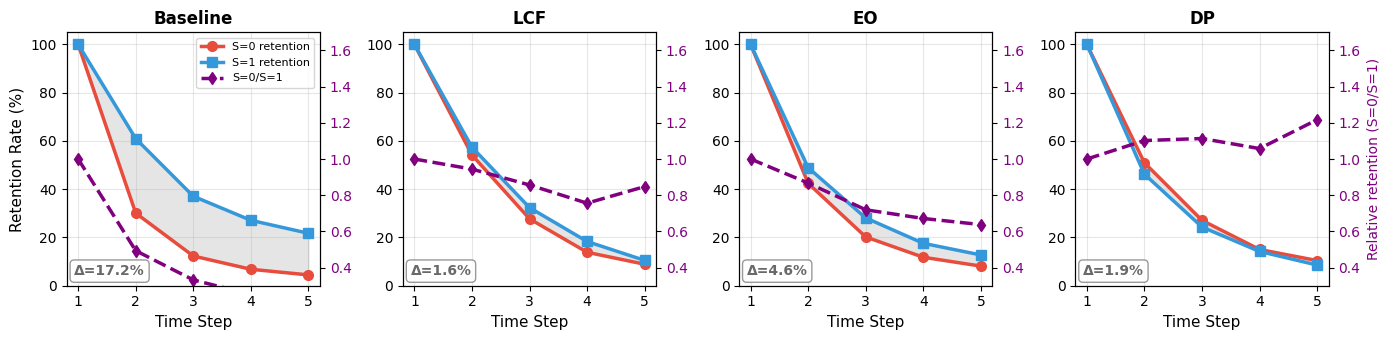

In [ ]:
steps = [1, 2, 3, 4, 5]
methods = ['Baseline', 'LCF', 'EO', 'DP']
left_colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}
ratio_color = 'purple'

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for idx, method in enumerate(methods):
    ax = axes[idx]; ax2 = ax.twinx()
    s0 = np.asarray(AGG[method]['R0'], float)
    s1 = np.asarray(AGG[method]['R1'], float)
    ratio = np.divide(s0, s1, out=np.full_like(s0, np.nan), where=(s1 != 0))

    l1, = ax.plot(steps, s0, 'o-', color=left_colors['S=0'], label='S=0 retention', linewidth=2.5, markersize=7)
    l2, = ax.plot(steps, s1, 's-', color=left_colors['S=1'], label='S=1 retention', linewidth=2.5, markersize=7)
    ax.fill_between(steps, s0, s1, alpha=0.2, color='gray')
    l3, = ax2.plot(steps, ratio, 'd--', color=ratio_color, label='S=0/S=1', linewidth=2.5, markersize=6)

    # single Δ label (final step, t=5) in bottom-left corner, clear of lines and legend
    ax.text(0.03, 0.03, f"Δ={AGG[method]['disparity'][-1]:.1f}%",
            transform=ax.transAxes, ha='left', va='bottom', fontsize=10,
            fontweight='bold', color='dimgray',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

    ax.set_title(method, fontsize=12, fontweight='bold'); ax.set_ylim(0, 105)
    ax.set_xticks(steps); ax.set_xlabel('Time Step', fontsize=11); ax.grid(True, alpha=0.3)
    ax2.set_ylim(0.3, 1.7); ax2.tick_params(axis='y', labelcolor=ratio_color)
    if idx == len(methods)-1:
        ax2.set_ylabel('Relative retention (S=0/S=1)', fontsize=10, color=ratio_color)
    if idx == 0:
        ax.set_ylabel('Retention Rate (%)', fontsize=11)
        ax.legend(handles=[l1, l2, l3], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('synth_retention.png', dpi=300, bbox_inches='tight')
plt.savefig('synth_retention.pdf', bbox_inches='tight')
plt.show()

In [ ]:
print(f"{'Model':<10}{'R0':>7}{'R1':>7}{'Δ':>7}{'p':>9}")
for name, model in models.items():
    r0s, r1s = [], []
    for sd in SEEDS:
        np.random.seed(sd)
        s,adj,e,Xs,Ys,Ds,Ps,Os,Us,As = run_simulation(
            decision_model=model, repayment_model=bank, agent=agent_test, steps=5,
            enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
            graph_seed=sd, seed=sd, decision_coef=1.0, repayment_coef=0.8, enable_opt_out=True)
        s_arr=np.array(s); A=np.array(As[-1])
        r0s.append(A[s_arr==0].mean()*100); r1s.append(A[s_arr==1].mean()*100)
    r0s,r1s=np.array(r0s),np.array(r1s)
    _,p = stats.ttest_rel(r0s, r1s)
    print(f"{name:<10}{r0s.mean():>7.1f}{r1s.mean():>7.1f}{r0s.mean()-r1s.mean():>+7.1f}{p:>9.1e}")

Model          R0     R1      Δ        p
Baseline      4.5   21.7  -17.2  3.6e-23
LCF           8.9   10.5   -1.6  5.1e-09
EO            8.1   12.8   -4.6  5.0e-13
DP           10.4    8.6   +1.9  1.4e-07


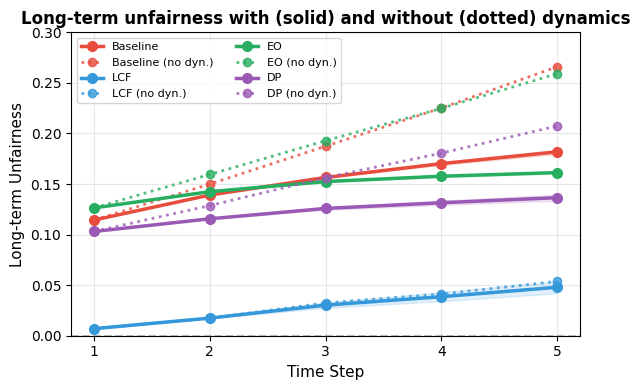

In [ ]:
colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'}

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for name in methods:
    a = AGG[name]
    ax.plot(steps, a['unf_dyn_mean'], 'o-', color=colors[name], label=name, linewidth=2.5, markersize=7)
    ax.fill_between(steps, a['unf_dyn_mean']-a['unf_dyn_std'], a['unf_dyn_mean']+a['unf_dyn_std'],
                    color=colors[name], alpha=0.15)
    ax.plot(steps, a['unf_stat_mean'], 'o:', color=colors[name], label=f'{name} (no dyn.)',
            linewidth=2, markersize=6, alpha=0.8)

ax.axhline(0.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Long-term Unfairness', fontsize=11)
ax.set_title('Long-term unfairness with (solid) and without (dotted) dynamics', fontsize=12, fontweight='bold')
ax.set_xticks(steps); ax.set_ylim(0, 0.3)
ax.legend(loc='upper left', fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('synth_unfairness_dynamics.png', dpi=300, bbox_inches='tight')
plt.savefig('synth_unfairness_dynamics.pdf', bbox_inches='tight')
plt.show()


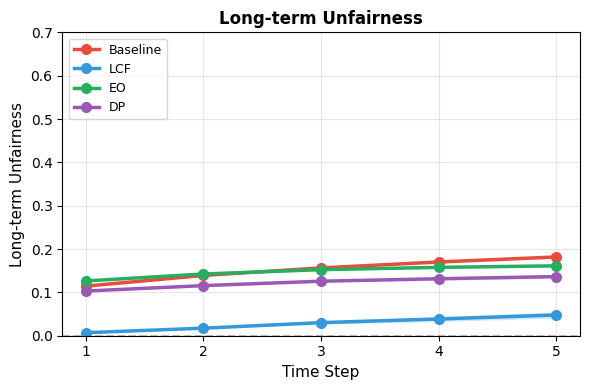

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for name in methods:
    ax.plot(steps, AGG[name]['unf_dyn_mean'], 'o-', color=colors[name], label=name,
            linewidth=2.5, markersize=7)
    ax.fill_between(steps, AGG[name]['unf_dyn_mean']-AGG[name]['unf_dyn_std'],
                    AGG[name]['unf_dyn_mean']+AGG[name]['unf_dyn_std'], color=colors[name], alpha=0.15)
ax.axhline(0.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Long-term Unfairness', fontsize=11)
ax.set_title('Long-term Unfairness', fontsize=12, fontweight='bold')
ax.set_xticks(steps); ax.set_ylim(0, 0.7)
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('synth_unfairness_merged.png', dpi=300, bbox_inches='tight')
plt.savefig('synth_unfairness_merged.pdf', bbox_inches='tight')
plt.show()

In [ ]:
print(f"{'Model':<10}{'LTF_dyn':>9}{'LTF_stat':>10}{'p':>8}")
print("-"*37)
for name in ['Baseline', 'LCF', 'EO', 'DP']:
    a = AGG[name]
    _, p = stats.ttest_rel(a['unf_stat_final'], a['unf_dyn_final'])
    sig = '*' if p < 0.05 else ''
    print(f"{name:<10}{a['unf_dyn_mean'][-1]:>9.3f}{a['unf_stat_mean'][-1]:>10.3f}{p:>7.2f}{sig}")

Model       LTF_dyn  LTF_stat       p
-------------------------------------
Baseline      0.182     0.266   0.00*
LCF           0.048     0.054   0.00*
EO            0.161     0.259   0.00*
DP            0.136     0.207   0.00*


In [ ]:
for m in ['Baseline','LCF','EO','DP']:
    a = AGG[m]
    print(m)
    print("  LTF_dyn :", np.round(a['unf_dyn_mean'],3).tolist())
    print("  R0      :", np.round(a['R0'],1).tolist())
    print("  R1      :", np.round(a['R1'],1).tolist())
    print("  disp    :", np.round(a['disparity'],1).tolist())

Baseline
  LTF_dyn : [0.114, 0.139, 0.156, 0.17, 0.182]
  R0      : [100.0, 30.1, 12.3, 6.8, 4.5]
  R1      : [100.0, 61.0, 37.1, 27.1, 21.7]
  disp    : [0.0, 30.9, 24.8, 20.3, 17.2]
LCF
  LTF_dyn : [0.007, 0.017, 0.03, 0.039, 0.048]
  R0      : [100.0, 54.2, 27.7, 13.9, 8.9]
  R1      : [100.0, 57.4, 32.4, 18.3, 10.5]
  disp    : [0.0, 3.2, 4.6, 4.5, 1.6]
EO
  LTF_dyn : [0.126, 0.142, 0.152, 0.158, 0.161]
  R0      : [100.0, 42.4, 20.2, 11.8, 8.1]
  R1      : [100.0, 48.9, 28.1, 17.6, 12.8]
  disp    : [0.0, 6.5, 7.9, 5.8, 4.6]
DP
  LTF_dyn : [0.103, 0.116, 0.126, 0.131, 0.136]
  R0      : [100.0, 51.0, 27.1, 15.0, 10.4]
  R1      : [100.0, 46.2, 24.3, 14.2, 8.6]
  disp    : [0.0, 4.7, 2.8, 0.8, 1.9]


In [ ]:
#add accuracy
from evaluation import compute_accuracy

def acc_run(model, seed):
    np.random.seed(seed)
    s,adj,e,Xs,Ys,Ds,Ps,Os,Us,As = run_simulation(
        decision_model=model, repayment_model=bank, agent=agent_test, steps=5,
        enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
        graph_seed=seed, seed=seed, decision_coef=1.0, repayment_coef=0.8, enable_opt_out=True)
    return np.array([compute_accuracy(s, Xs[t], Ys[t], model) for t in range(len(Xs))])

for name, model in models.items():
    AGG[name]['acc'] = np.nanmean([acc_run(model, sd) for sd in SEEDS], 0) * 100
print({k: np.round(AGG[k]['acc'],1).tolist() for k in models})

{'Baseline': [70.4, 74.0, 72.7, 74.0, 74.4], 'LCF': [68.5, 71.3, 71.5, 71.1, 71.2], 'EO': [68.9, 74.1, 72.7, 73.5, 74.3], 'DP': [67.7, 71.7, 72.2, 72.7, 72.8]}


## detailed metrics for signed differences and conditional fairness

In [ ]:
def detailed_one_run(model, seed):
    np.random.seed(seed)
    s, adj, e, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation(
        decision_model=model, repayment_model=bank, agent=agent_test, steps=5,
        enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
        graph_seed=seed, seed=seed, decision_coef=1.0, repayment_coef=0.8, enable_opt_out=True)
    s = np.array(s); n0 = np.sum(s==0); n1 = np.sum(s==1)
    rep, sig, hs0, hs1, hr = [], [], [], [], []
    prev0 = prev1 = None
    for t in range(len(As)):
        A = np.array(As[t]); D = np.array(Ds[t])
        a0 = np.sum((s==0)&(A==1)); a1 = np.sum((s==1)&(A==1))
        r0 = a0/n0*100 if n0 else np.nan; r1 = a1/n1*100 if n1 else np.nan
        rep.append(r0/r1 if r1 else np.nan)
        m0 = (s==0)&(A==1); m1 = (s==1)&(A==1)
        d0 = np.mean(D[m0]==1) if m0.any() else np.nan
        d1 = np.mean(D[m1]==1) if m1.any() else np.nan
        sig.append(d0-d1 if (m0.any() and m1.any()) else np.nan)
        if t==0: h0=h1=1.0
        else:
            h0 = a0/prev0 if prev0 else np.nan
            h1 = a1/prev1 if prev1 else np.nan
        hs0.append(h0); hs1.append(h1); hr.append(h0/h1 if h1 else np.nan)
        prev0, prev1 = a0, a1
    return np.array(rep), np.array(sig), np.array(hs0), np.array(hs1), np.array(hr)

for name, model in models.items():
    runs = [detailed_one_run(model, sd) for sd in SEEDS]
    AGG[name]['rep_ratio']    = np.nanmean([r[0] for r in runs], 0)
    AGG[name]['signed_delta'] = np.nanmean([r[1] for r in runs], 0)
    AGG[name]['h_s0']         = np.nanmean([r[2] for r in runs], 0)
    AGG[name]['h_s1']         = np.nanmean([r[3] for r in runs], 0)
    AGG[name]['h_ratio']      = np.nanmean([r[4] for r in runs], 0)
print("detailed metrics added to AGG")

detailed metrics added to AGG


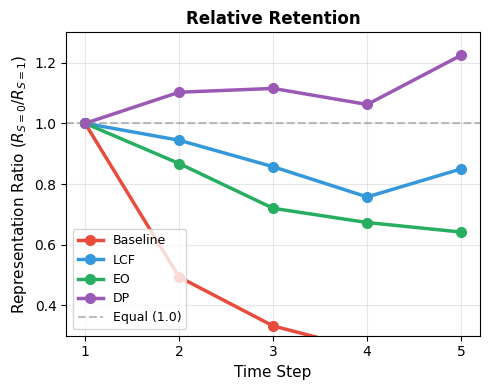

In [ ]:
import matplotlib.pyplot as plt
steps = [1,2,3,4,5]; methods = ['Baseline','LCF','EO','DP']
colors = {'Baseline':'#E74C3C','LCF':'#3498DB','EO':'#27AE60','DP':'#9B59B6'}

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
for m in methods:
    ax.plot(steps, AGG[m]['rep_ratio'], 'o-', color=colors[m], label=m, linewidth=2.5, markersize=7)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Representation Ratio ($R_{S=0}/R_{S=1}$)', fontsize=11)
ax.set_title('Relative Retention', fontsize=12, fontweight='bold')
ax.set_ylim(0.3, 1.3); ax.set_xticks(steps)
ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('synth_relative_retention.png', dpi=300, bbox_inches='tight')
plt.savefig('synth_relative_retention.pdf', bbox_inches='tight')
plt.show()

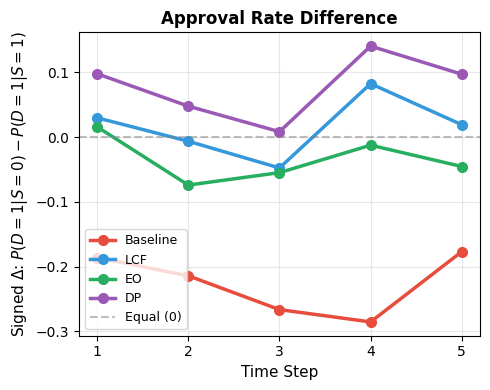

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
for m in methods:
    ax.plot(steps, AGG[m]['signed_delta'], 'o-', color=colors[m], label=m, linewidth=2.5, markersize=7)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Signed $\\Delta$: $P(D{=}1|S{=}0)-P(D{=}1|S{=}1)$', fontsize=11)
ax.set_title('Approval Rate Difference', fontsize=12, fontweight='bold')
ax.set_xticks(steps)
ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('synth_approval_diff.png', dpi=300, bbox_inches='tight')
plt.savefig('synth_approval_diff.pdf', bbox_inches='tight')
plt.show()

In [ ]:
'''# NEW: Cummulative difference H (t+1/t)
def compute_detailed_metrics(s, As, Ds, Ys):
    """Compute signed differences, group sizes, representation ratios, and stepwise retention multipliers."""
    s = np.array(s)
    n_s0_total = np.sum(s == 0)
    n_s1_total = np.sum(s == 1)

    print("Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)")
    print("-" * 120)

    metrics = {
        's0_share': [],
        'rep_ratio': [],
        'signed_delta': [],
        'retention_s0': [],
        'retention_s1': [],
        'disparity': [],
        # Stepwise retention multipliers ("hazard" of staying in, per step)
        'h_s0': [],
        'h_s1': [],
        'h_ratio': []
    }

    prev_active_s0 = None
    prev_active_s1 = None

    for t in range(len(As)):
        A_t = np.array(As[t])
        D_t = np.array(Ds[t])

        # Active counts per group
        active_s0 = np.sum((s == 0) & (A_t == 1))
        active_s1 = np.sum((s == 1) & (A_t == 1))
        total_active = active_s0 + active_s1

        # S=0 share of active population
        s0_share = active_s0 / total_active if total_active > 0 else 0

        # Retention rates (relative to initial group size)
        retention_s0 = (active_s0 / n_s0_total) * 100 if n_s0_total > 0 else np.nan
        retention_s1 = (active_s1 / n_s1_total) * 100 if n_s1_total > 0 else np.nan
        disparity = abs(retention_s0 - retention_s1)

        # Representation ratio of retention
        rep_ratio = retention_s0 / retention_s1 if retention_s1 and retention_s1 > 0 else np.nan

        # Stepwise retention multipliers: N_t / N_{t-1}
        if t == 0:
            h_s0 = 1.0
            h_s1 = 1.0
        else:
            h_s0 = (active_s0 / prev_active_s0) if (prev_active_s0 is not None and prev_active_s0 > 0) else np.nan
            h_s1 = (active_s1 / prev_active_s1) if (prev_active_s1 is not None and prev_active_s1 > 0) else np.nan
        h_ratio = (h_s0 / h_s1) if (h_s1 is not None and not np.isnan(h_s1) and h_s1 != 0) else np.nan

        prev_active_s0 = active_s0
        prev_active_s1 = active_s1

        # Signed approval rate difference (among active only)
        active_mask = A_t == 1
        if active_s0 > 0 and active_s1 > 0:
            approval_s0 = np.mean(D_t[(s == 0) & active_mask])
            approval_s1 = np.mean(D_t[(s == 1) & active_mask])
            signed_delta = approval_s0 - approval_s1  # Negative = S=0 disadvantaged
        else:
            signed_delta = np.nan

        # Store metrics
        metrics['s0_share'].append(s0_share)
        metrics['rep_ratio'].append(rep_ratio)
        metrics['signed_delta'].append(signed_delta)
        metrics['retention_s0'].append(retention_s0)
        metrics['retention_s1'].append(retention_s1)
        metrics['disparity'].append(disparity)
        metrics['h_s0'].append(h_s0)
        metrics['h_s1'].append(h_s1)
        metrics['h_ratio'].append(h_ratio)

        print(
            f"  {t+1}  |"
            f"  {active_s0:4d}  |"
            f"  {active_s1:4d}  |"
            f"   {s0_share:.2f}    |"
            f"    {rep_ratio:6.2f}  |"
            f"  {h_s0:5.2f}  |"
            f"  {h_s1:5.2f}  |"
            f"  {h_ratio:6.2f}  |"
            f"      {signed_delta:+.3f}"
        )

    return metrics

# Run for each method
print("\n=== Baseline ===")
metrics_baseline = compute_detailed_metrics(results_baseline['s'], results_baseline['As'], results_baseline['Ds'], results_baseline['Ys'])

print("\n=== LCF ===")
metrics_LCF = compute_detailed_metrics(results_lcf['s'], results_lcf['As'], results_lcf['Ds'], results_lcf['Ys'])

print("\n=== EO ===")
metrics_eo = compute_detailed_metrics(results_eo['s'], results_eo['As'], results_eo['Ds'], results_eo['Ys'])

print("\n=== DP ===")
metrics_dp = compute_detailed_metrics(results_dp['s'], results_dp['As'], results_dp['Ds'], results_dp['Ys'])'''

'# NEW: Cummulative difference H (t+1/t)\ndef compute_detailed_metrics(s, As, Ds, Ys):\n    """Compute signed differences, group sizes, representation ratios, and stepwise retention multipliers."""\n    s = np.array(s)\n    n_s0_total = np.sum(s == 0)\n    n_s1_total = np.sum(s == 1)\n\n    print("Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)")\n    print("-" * 120)\n\n    metrics = {\n        \'s0_share\': [],\n        \'rep_ratio\': [],\n        \'signed_delta\': [],\n        \'retention_s0\': [],\n        \'retention_s1\': [],\n        \'disparity\': [],\n        # Stepwise retention multipliers ("hazard" of staying in, per step)\n        \'h_s0\': [],\n        \'h_s1\': [],\n        \'h_ratio\': []\n    }\n\n    prev_active_s0 = None\n    prev_active_s1 = None\n\n    for t in range(len(As)):\n        A_t = np.array(As[t])\n        D_t = np.array(Ds[t])\n\n        # Active counts per group\n        active_s0 = np.sum((s == 0) & (A_t